# Numeric Forecast Scenarios - Probit Aggregation Analysis

**Date**: January 28, 2026  
**Purpose**: Visualize cumulative distributions using Probit aggregation for numeric questions  
**Data Source**: JSON scenario files from `all_forecast_summaries/`

## Probit Aggregation Method
Instead of GPR, this notebook uses probit (normal distribution) fitting:
1. Sort scenario values and assign percentiles
2. Transform percentiles to z-scores (probit scale)
3. Linear regression of values against z-scores
4. Extract any percentile from fitted line

**Benefits:**
- Assumes normal distribution, which smooths the curve
- Allows extrapolation to extreme percentiles (p1, p99)
- Avoids GPR edge artifacts at high/low percentiles

## Questions Analyzed
- 41614 - unknown tournament
- 41619 - unknown tournament  
- 41750 - Spring AIB 2026
- 41752 - Spring AIB 2026
- 41871 - Spring AIB 2026
- 41875 - Spring AIB 2026

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import probscale

# For probit transformation
from scipy.integrate import quad
from scipy.interpolate import splrep, splev
from scipy.stats import linregress

In [2]:
# Core Functions: Probit Transformation

def pdf_normal(z): 
    """Normal distribution PDF."""
    return (1 / ((2 * np.pi))**0.5) * np.exp(-0.5 * (z**2))

def pcntl_from_z(z):
    """Calculate percentile from z-score by integrating from -inf to z."""
    return quad(pdf_normal, -np.inf, z)[0]

def z_from_pcntl(percentile):
    """Calculate z-score from percentile using spline interpolation."""
    x = [pcntl_from_z(z) for z in np.arange(-7, 7.01, 0.01)]
    z = list(np.arange(-7, 7.01, 0.01))
    zspline = splrep(x, z)
    return splev(percentile, zspline)

def probit_fit(data, key_pctls=np.array([1, 5, 10, 25, 50, 75, 90, 95, 99])):
    """
    Fit normal distribution to data using probit regression.
    
    Returns: dict with slope, intercept, r2, and key percentile values
    """
    # Prep data
    data_sorted = np.sort(data)
    n_points = data.shape[0]
    pctl = 100 * np.array(range(1, n_points + 1)) / (n_points + 1)
    
    # Linearize: convert percentiles to z-scores
    ztile = z_from_pcntl(pctl / 100)
    
    # Regression of data values against z
    slope, intercept, r_value, p_value, std_err = linregress(ztile, data_sorted)
    
    # Evaluate regression for key percentiles
    key_ztile = z_from_pcntl(key_pctls / 100)
    key_values = [z * slope + intercept for z in key_ztile]
    
    return {
        'slope': slope,           # ~ standard deviation
        'intercept': intercept,   # ~ mean (value at z=0, i.e., p50)
        'r2': r_value**2,
        'key_pctls': key_pctls,
        'key_values': key_values,
        'data_sorted': data_sorted,
        'data_pctl': pctl,
        'data_ztile': ztile
    }

In [3]:
# Data loading and processing functions

def load_scenario_data(question_id, data_path):
    """
    Load scenario data from JSON file for a numeric question.
    Returns the raw scenario values and metadata.
    """
    # Find the JSON file for this question
    json_files = list(data_path.glob(f"{question_id}_*_scenarios_*.json"))
    
    if not json_files:
        print(f"Warning: No scenario file found for question {question_id}")
        return None
    
    json_file = json_files[0]  # Take first match
    
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Extract raw scenario values
    raw_values = np.array(data['scenarios']['raw_values'])
    metadata = data['metadata']
    aggregated = data['aggregated_result']
    summary = data['summary']
    
    return {
        'raw_values': raw_values,
        'metadata': metadata,
        'aggregated': aggregated,
        'summary': summary,
        'filename': json_file.name
    }

def make_percentiles(sorted_data):
    """
    Calculate percentile values for each data point.
    """
    pctl = [100 * i/(1 + len(sorted_data)) for i, row in enumerate(sorted_data)]
    return pctl

In [4]:
# Configuration

# Numeric question IDs to analyze
question_ids = [41614, 41619, 41750, 41752, 41871, 41875]

# Path to forecast summaries
data_path = Path("../all_forecast_summaries")

# Plot configuration
use_probit_smoothing = True  # Set to False to plot raw scenarios only
use_prob_scale = True        # Use probability scale for axes

In [5]:
# Plotting function

def plot_forecast_distribution(question_id, sorted_data, pctl, probit_result=None, 
                               metadata=None, summary=None, aggregated=None,
                               use_prob_scale=True):
    """
    Plot the cumulative distribution of forecast scenarios with probit fit.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Question info
    q_text = metadata.get('question_text', 'Unknown')[:60] + "..."
    tournament = metadata.get('tournament', 'Unknown')
    units = metadata.get('units', '')
    
    # Plot raw scenarios
    ax.scatter(sorted_data, pctl, s=25, alpha=0.5, label='Raw scenarios', color='gray')
    
    # Plot Probit fit if available
    if probit_result is not None:
        r2 = probit_result['r2']
        probit_p50 = probit_result['intercept']
        
        ax.scatter(probit_result['key_values'], probit_result['key_pctls'], 
                  c='red', s=60, alpha=0.6, label=f'Probit fit (R²={r2:.4f})', zorder=5)
        ax.plot(probit_result['key_values'], probit_result['key_pctls'], 
               'r-', linewidth=1.5, alpha=0.5, zorder=4)
        
        # Add annotations for key percentiles
        for i, (p, v) in enumerate(zip(probit_result['key_pctls'], probit_result['key_values'])):
            if p in [1, 25, 50, 75, 99]:  # Annotate only key percentiles
                ax.annotate(f'{v:.2f}', (v, p), fontsize=8, 
                           xytext=(5, 0), textcoords='offset points')
    
    # Add summary statistics
    if summary and probit_result:
        stats_text = f"Raw Stats:\n"
        stats_text += f"Min: {summary['min_value']:.2f}\n"
        stats_text += f"Median: {summary['median_value']:.2f}\n"
        stats_text += f"Max: {summary['max_value']:.2f}\n"
        stats_text += f"Std: {summary['std_value']:.2f}\n\n"
        stats_text += f"Probit Stats:\n"
        stats_text += f"Mean: {probit_result['intercept']:.2f}\n"
        stats_text += f"Std: {probit_result['slope']:.2f}"
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Formatting
    ax.set_xlabel(f"Forecast Value ({units})" if units else "Forecast Value", fontsize=11)
    ax.set_ylabel("Percentile", fontsize=11)
    ax.set_title(f"Question {question_id}: {q_text}\n{tournament}", fontsize=12, pad=15)
    
    if use_prob_scale:
        ax.set_yscale('prob')
        ax.set_ylim(bottom=1, top=99)
    else:
        ax.set_ylim(bottom=0, top=100)
    
    ax.grid(True, alpha=0.3, which='both')
    ax.grid(True, alpha=0.2, which='minor')
    ax.legend(loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## Load and Process All Questions

This cell loads the scenario data for all numeric questions and prepares it for plotting.

In [6]:
# Load all question data

all_question_data = {}

print("Loading scenario data for numeric questions...")
print("=" * 80)

for qid in question_ids:
    data = load_scenario_data(qid, data_path)
    
    if data is None:
        continue
    
    # Store the data
    all_question_data[qid] = data
    
    # Print summary
    print(f"Question {qid}:")
    print(f"  File: {data['filename']}")
    print(f"  Scenarios: {len(data['raw_values'])}")
    print(f"  Range: {data['summary']['min_value']:.2f} - {data['summary']['max_value']:.2f}")
    print(f"  Median: {data['summary']['median_value']:.2f}")
    print()

print(f"✓ Loaded {len(all_question_data)} questions successfully")

Loading scenario data for numeric questions...
Question 41614:
  File: 41614_unknown_scenarios_1.json
  Scenarios: 36
  Range: 4.25 - 5.30
  Median: 4.71

Question 41619:
  File: 41619_unknown_scenarios_1.json
  Scenarios: 36
  Range: 4.25 - 5.55
  Median: 4.82

Question 41750:
  File: 41750_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 14.00 - 15.50
  Median: 14.75

Question 41752:
  File: 41752_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 429.50 - 435.00
  Median: 432.25

Question 41871:
  File: 41871_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 6000000000.00 - 8000000000.00
  Median: 6975000000.00

Question 41875:
  File: 41875_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 36.00 - 47.00
  Median: 41.85

✓ Loaded 6 questions successfully


## Plot Cumulative Distributions

Generate cumulative distribution plots with probit fitting for each numeric question.

Generating cumulative distribution plots...



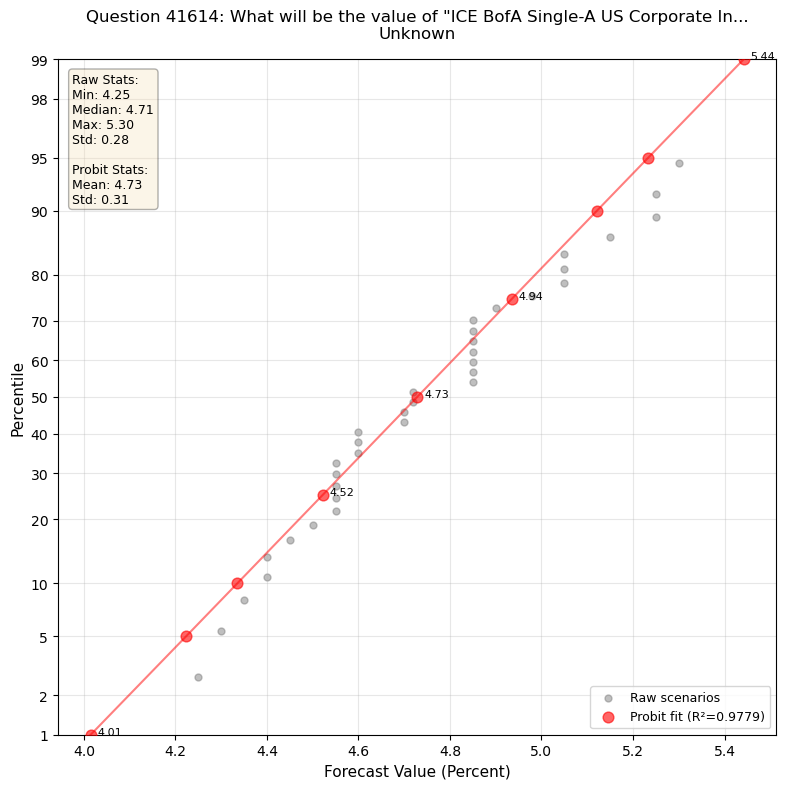

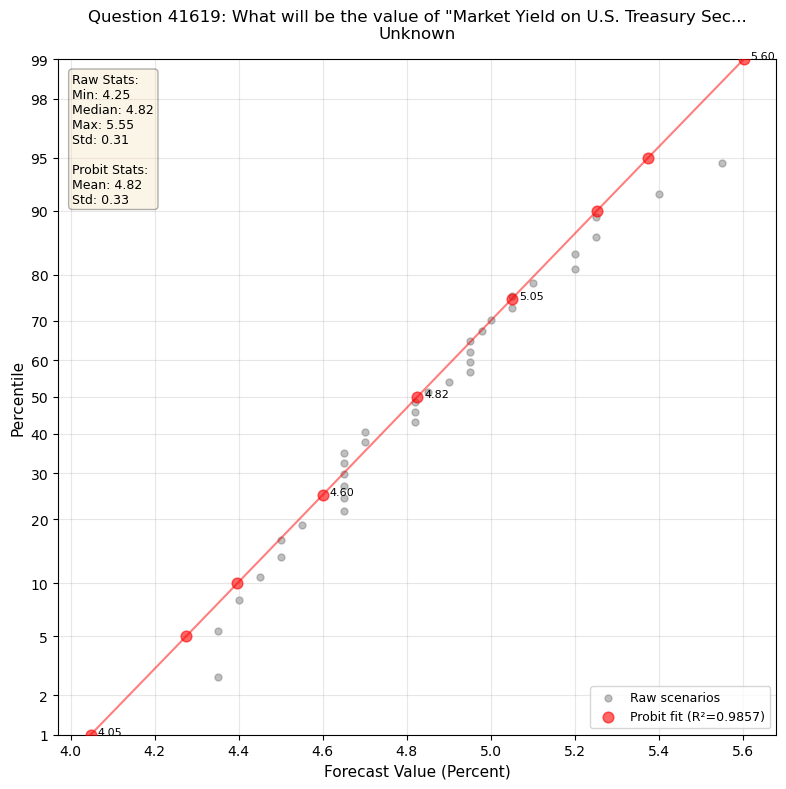

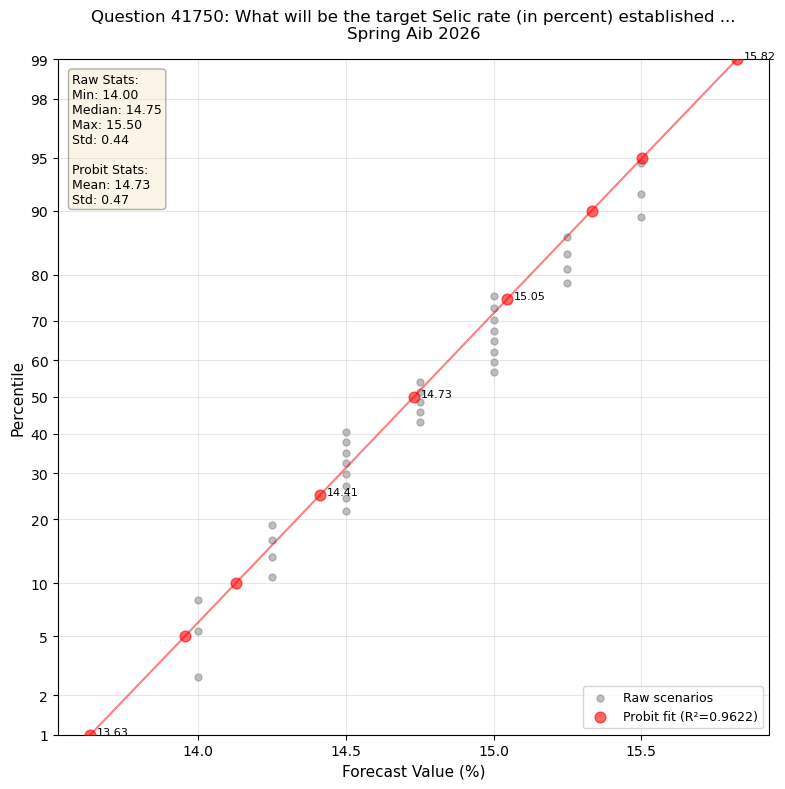

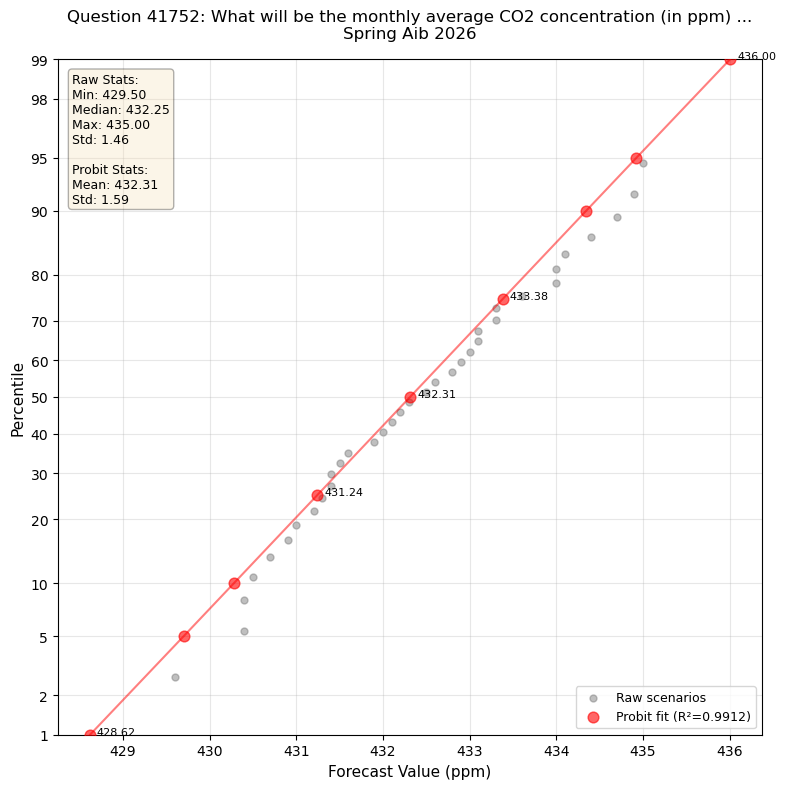

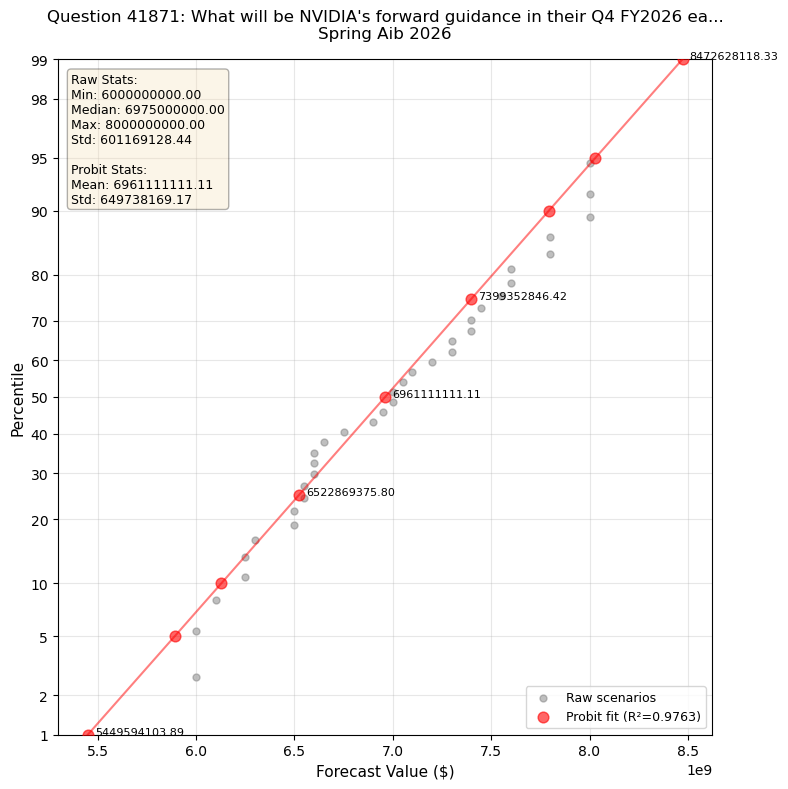

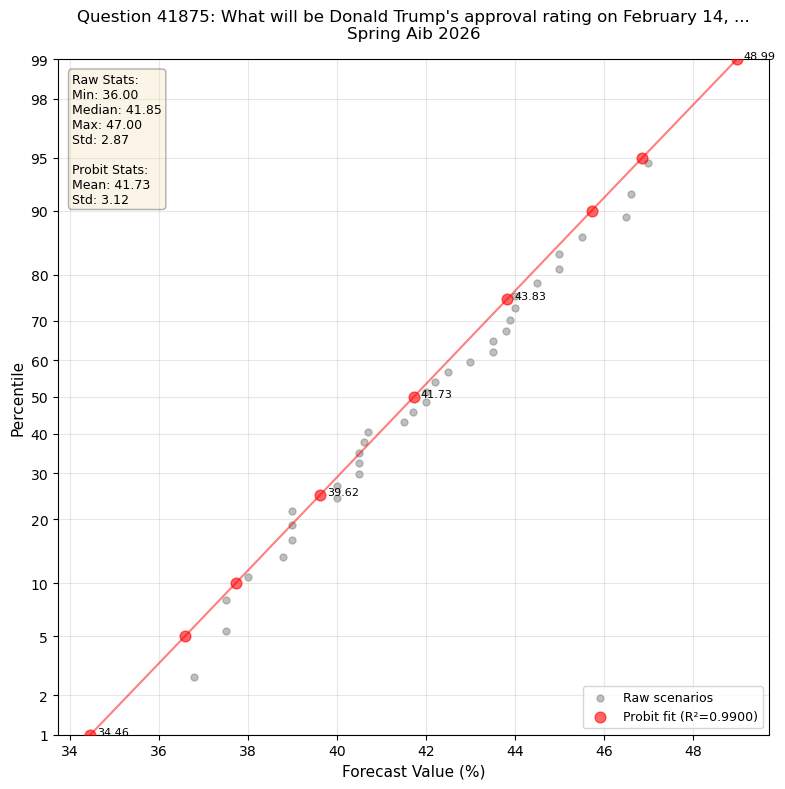


✓ All plots generated


In [7]:
# Generate plots for all questions

print("Generating cumulative distribution plots...")
print("=" * 80)
print()

for qid in question_ids:
    if qid not in all_question_data:
        print(f"Skipping question {qid} (no data)")
        continue
    
    data = all_question_data[qid]
    
    # Process the data
    sorted_data = np.sort(data['raw_values'])
    pctl = make_percentiles(sorted_data)
    
    # Fit probit model if enabled
    probit_result = None
    if use_probit_smoothing:
        try:
            probit_result = probit_fit(data['raw_values'])
        except Exception as e:
            print(f"Warning: Probit fitting failed for question {qid}: {e}")
    
    # Plot
    plot_forecast_distribution(
        question_id=qid,
        sorted_data=sorted_data,
        pctl=pctl,
        probit_result=probit_result,
        metadata=data['metadata'],
        summary=data['summary'],
        aggregated=data['aggregated'],
        use_prob_scale=use_prob_scale
    )

print("\n✓ All plots generated")

## Comparative Analysis

Compare distributions across all questions (normalized scale).

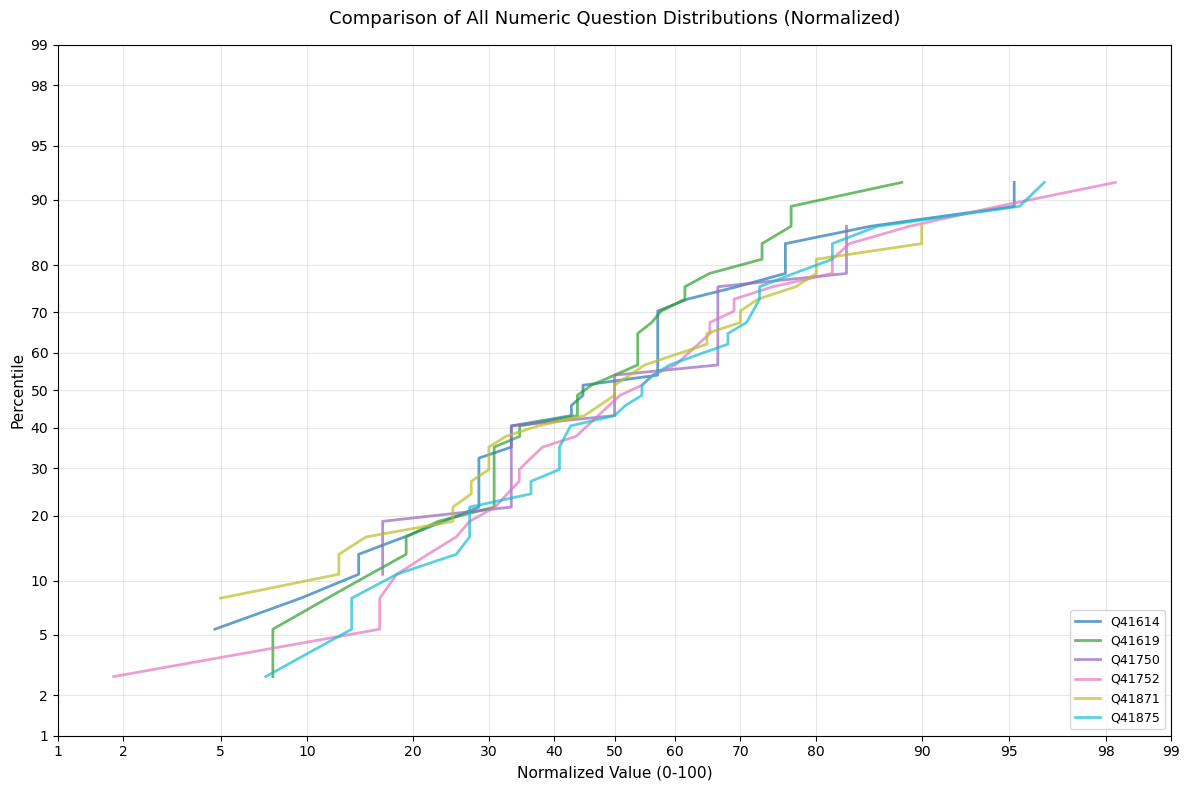

In [8]:
# Create a comparison plot showing all distributions together

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(question_ids)))

for idx, qid in enumerate(question_ids):
    if qid not in all_question_data:
        continue
    
    data = all_question_data[qid]
    sorted_data = np.sort(data['raw_values'])
    pctl = make_percentiles(sorted_data)
    
    # Normalize to 0-100 scale for comparison
    min_val = min(sorted_data)
    max_val = max(sorted_data)
    normalized = [(x - min_val) / (max_val - min_val) * 100 for x in sorted_data]
    
    # Use plot to show lines
    ax.plot(normalized, pctl, linewidth=2, alpha=0.7, 
            label=f'Q{qid}', color=colors[idx])

ax.set_xlabel("Normalized Value (0-100)", fontsize=11)
ax.set_ylabel("Percentile", fontsize=11)
ax.set_title("Comparison of All Numeric Question Distributions (Normalized)", fontsize=13, pad=15)

if use_prob_scale:
    ax.set_xscale('prob')
    ax.set_yscale('prob')
    ax.set_xlim(left=1, right=99)
    ax.set_ylim(bottom=1, top=99)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

## Summary Statistics Table

In [9]:
# Create a summary table of all questions with probit fit statistics

summary_data = []

for qid in question_ids:
    if qid not in all_question_data:
        continue
    
    data = all_question_data[qid]
    summary = data['summary']
    metadata = data['metadata']
    
    # Fit probit model for this question
    try:
        probit_result = probit_fit(data['raw_values'], 
                                   key_pctls=np.array([1, 25, 50, 75, 99]))
        probit_p1 = probit_result['key_values'][0]
        probit_p25 = probit_result['key_values'][1]
        probit_p50 = probit_result['key_values'][2]
        probit_p75 = probit_result['key_values'][3]
        probit_p99 = probit_result['key_values'][4]
        probit_r2 = probit_result['r2']
    except:
        probit_p1 = probit_p25 = probit_p50 = probit_p75 = probit_p99 = probit_r2 = np.nan
    
    summary_data.append({
        'Question ID': qid,
        'Tournament': metadata.get('tournament', 'Unknown'),
        'Units': metadata.get('units', ''),
        'N Scenarios': len(data['raw_values']),
        'Raw Min': summary['min_value'],
        'Raw Median': summary['median_value'],
        'Raw Max': summary['max_value'],
        'Raw Std': summary['std_value'],
        'Probit p1': probit_p1,
        'Probit p25': probit_p25,
        'Probit p50': probit_p50,
        'Probit p75': probit_p75,
        'Probit p99': probit_p99,
        'Probit R²': probit_r2
    })

df_summary = pd.DataFrame(summary_data)
# Round to 2 decimal places for readability
numeric_cols = df_summary.select_dtypes(include=[np.number]).columns
df_summary[numeric_cols] = df_summary[numeric_cols].round(2)

print("\nSummary Statistics for All Numeric Questions:")
print("=" * 140)
display(df_summary)

# Export to CSV
output_file = data_path.parent / 'numeric_forecast_summary_statistics_probit.csv'
df_summary.to_csv(output_file, index=False)
print(f"\n✓ Summary statistics saved to: {output_file}")


Summary Statistics for All Numeric Questions:


,Question ID,Tournament,Units,N Scenarios,Raw Min,Raw Median,Raw Max,Raw Std,Probit p1,Probit p25,Probit p50,Probit p75,Probit p99,Probit R²
0,41614,Unknown,Percent,36,4.250000e+00,4.710000e+00,5.300000e+00,2.800000e-01,4.010000e+00,4.520000e+00,4.730000e+00,4.940000e+00,5.440000e+00,0.98
1,41619,Unknown,Percent,36,4.250000e+00,4.820000e+00,5.550000e+00,3.100000e-01,4.050000e+00,4.600000e+00,4.820000e+00,5.050000e+00,5.600000e+00,0.99
2,41750,Spring Aib 2026,%,36,1.400000e+01,1.475000e+01,1.550000e+01,4.400000e-01,1.363000e+01,1.441000e+01,1.473000e+01,1.505000e+01,1.582000e+01,0.96
3,41752,Spring Aib 2026,ppm,36,4.295000e+02,4.322500e+02,4.350000e+02,1.460000e+00,4.286200e+02,4.312400e+02,4.323100e+02,4.333800e+02,4.360000e+02,0.99
4,41871,Spring Aib 2026,$,36,6.000000e+09,6.975000e+09,8.000000e+09,6.011691e+08,5.449594e+09,6.522869e+09,6.961111e+09,7.399353e+09,8.472628e+09,0.98
5,41875,Spring Aib 2026,%,36,3.600000e+01,4.185000e+01,4.700000e+01,2.870000e+00,3.446000e+01,3.962000e+01,4.173000e+01,4.383000e+01,4.899000e+01,0.99



✓ Summary statistics saved to: ..\numeric_forecast_summary_statistics_probit.csv


## Probit vs GPR Comparison (Optional)

Compare probit fit percentiles with existing GPR percentiles from the JSON files.

In [10]:
# Compare Probit vs GPR for all questions

comparison_data = []

for qid in question_ids:
    if qid not in all_question_data:
        continue
    
    data = all_question_data[qid]
    
    # Check if GPR percentiles exist in the data
    if 'aggregated' not in data or data['aggregated'] is None:
        print(f"Warning: No aggregated_result found for question {qid}, skipping comparison")
        continue
    
    if 'percentiles' not in data['aggregated']:
        print(f"Warning: No percentiles found in aggregated_result for question {qid}, skipping comparison")
        continue
    
    gpr_pctls = data['aggregated']['percentiles']
    
    # Get probit values at same percentiles as GPR
    gpr_percentiles = [5, 25, 50, 75, 95]
    probit_result = probit_fit(data['raw_values'], key_pctls=np.array(gpr_percentiles))
    
    for i, p in enumerate(gpr_percentiles):
        gpr_val = gpr_pctls.get(f'p{p}', np.nan)
        probit_val = probit_result['key_values'][i]
        diff = probit_val - gpr_val
        diff_pct = 100 * diff / gpr_val if gpr_val != 0 else np.nan
        
        comparison_data.append({
            'Question': qid,
            'Percentile': f'p{p}',
            'GPR': gpr_val,
            'Probit': probit_val,
            'Diff': diff,
            'Diff %': diff_pct
        })

if len(comparison_data) > 0:
    df_comparison = pd.DataFrame(comparison_data)
    numeric_cols = df_comparison.select_dtypes(include=[np.number]).columns
    df_comparison[numeric_cols] = df_comparison[numeric_cols].round(2)

    print("\nProbit vs GPR Comparison:")
    print("=" * 100)
    display(df_comparison)

    # Summary statistics on differences
    print("\nDifference Statistics:")
    print(f"Mean absolute difference: {df_comparison['Diff'].abs().mean():.3f}")
    print(f"Mean percentage difference: {df_comparison['Diff %'].abs().mean():.2f}%")
    print(f"Max absolute difference: {df_comparison['Diff'].abs().max():.3f}")
else:
    print("\nNo GPR data available for comparison.")


Probit vs GPR Comparison:


,Question,Percentile,GPR,Probit,Diff,Diff %
0,41614,p5,4.270000e+00,4.220000e+00,-4.000000e-02,-1.04
1,41614,p25,4.510000e+00,4.520000e+00,1.000000e-02,0.28
2,41614,p50,4.710000e+00,4.730000e+00,2.000000e-02,0.47
3,41614,p75,4.940000e+00,4.940000e+00,-1.000000e-02,-0.13
4,41614,p95,5.250000e+00,5.230000e+00,-2.000000e-02,-0.34
5,41619,p5,4.310000e+00,4.280000e+00,-3.000000e-02,-0.80
6,41619,p25,4.590000e+00,4.600000e+00,0.000000e+00,0.10
7,41619,p50,4.810000e+00,4.820000e+00,2.000000e-02,0.34
8,41619,p75,5.050000e+00,5.050000e+00,0.000000e+00,0.09
9,41619,p95,5.400000e+00,5.370000e+00,-2.000000e-02,-0.43



Difference Statistics:
Mean absolute difference: 4608278.917
Mean percentage difference: 0.24%
Max absolute difference: 108413072.380
